In [1]:
import numpy as ap
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection  import train_test_split
import joblib 

In [6]:
df=pd.read_csv("creditcard.csv")
print(df)

            Time         V1         V2  ...       V28  Amount  Class
0            0.0  -1.359807  -0.072781  ... -0.021053  149.62      0
1            0.0   1.191857   0.266151  ...  0.014724    2.69      0
2            1.0  -1.358354  -1.340163  ... -0.059752  378.66      0
3            1.0  -0.966272  -0.185226  ...  0.061458  123.50      0
4            2.0  -1.158233   0.877737  ...  0.215153   69.99      0
...          ...        ...        ...  ...       ...     ...    ...
284802  172786.0 -11.881118  10.071785  ...  0.823731    0.77      0
284803  172787.0  -0.732789  -0.055080  ... -0.053527   24.79      0
284804  172788.0   1.919565  -0.301254  ... -0.026561   67.88      0
284805  172788.0  -0.240440   0.530483  ...  0.104533   10.00      0
284806  172792.0  -0.533413  -0.189733  ...  0.013649  217.00      0

[284807 rows x 31 columns]


In [8]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df["Class"].value_counts()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

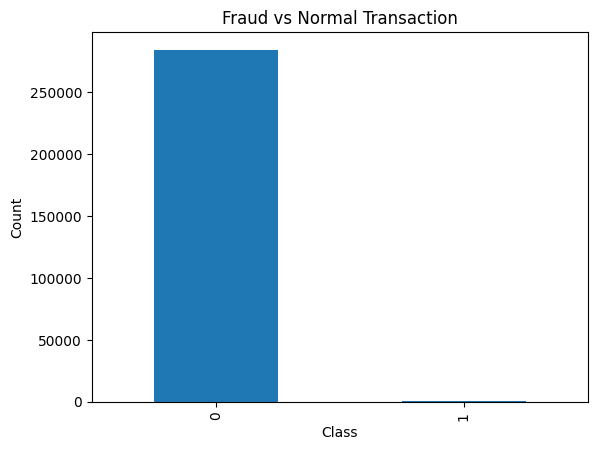

In [9]:
df["Class"].value_counts().plot(kind="bar")

plt.title("Fraud vs Normal Transaction")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [10]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
fraud = df["Class"].value_counts()[1]
normal = df["Class"].value_counts()[0]

print("Fraud Percentage:", (fraud/len(df))*100)
print("Normal Percentage:", (normal/len(df))*100)

Fraud Percentage: 0.1727485630620034
Normal Percentage: 99.82725143693798


In [12]:
X=df.drop("Class",axis=1)
y=df["Class"]

print (X.shape)
print (y.shape)


(284807, 30)
(284807,)


In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [18]:
scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])

X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)



print(classification_report(y_test, y_pred))

[[56851    13]
 [   35    63]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:

joblib.dump(model, "fraud_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [21]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully
